In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file Excel từ máy tính của bạn
# Tham số header=1 vì dòng đầu tiên của file này là X1, X2... Dòng thứ 2 mới là tên cột chuẩn
df = pd.read_excel('default of credit card clients.xls', header=1)

# Xóa cột ID đi vì nó chỉ là số thứ tự, không dùng để chạy AI
df = df.drop(columns=['ID'])

# Đổi tên biến mục tiêu cho ngắn gọn dễ thao tác
df = df.rename(columns={'default payment next month': 'default'})

print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


--- THÔNG TIN TỔNG QUAN ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


C:\Users\HP\AppData\Local\Temp\ipykernel_17204\1322908007.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='default', data=df, palette='Set2')


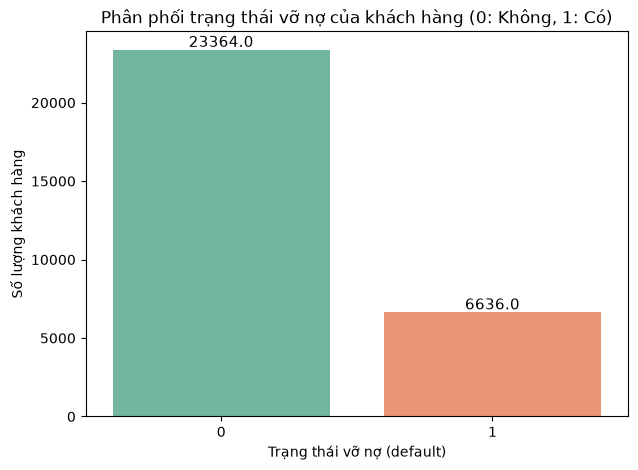

Tỷ lệ không vỡ nợ: 77.88%
Tỷ lệ vỡ nợ: 22.12%


In [3]:
# 1. Xem thông tin tổng quan (kiểu dữ liệu, số giá trị bị thiếu)
print("--- THÔNG TIN TỔNG QUAN ---")
df.info()

print("\n" + "="*50 + "\n")

# 2. Thống kê mô tả (Trung bình, độ lệch chuẩn, Min, Max của từng biến)
print("--- THỐNG KÊ MÔ TẢ ---")
display(df.describe().T)

# 3. Vẽ biểu đồ phân phối biến mục tiêu (Khách hàng vỡ nợ vs Không vỡ nợ)
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='default', data=df, palette='Set2')

# Thêm số lượng cụ thể lên đầu mỗi cột biểu đồ cho trực quan
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Phân phối trạng thái vỡ nợ của khách hàng (0: Không, 1: Có)')
plt.xlabel('Trạng thái vỡ nợ (default)')
plt.ylabel('Số lượng khách hàng')
plt.show()

# Tính tỷ lệ phần trăm
ti_le = df['default'].value_counts(normalize=True) * 100
print(f"Tỷ lệ không vỡ nợ: {ti_le[0]:.2f}%")
print(f"Tỷ lệ vỡ nợ: {ti_le[1]:.2f}%")